<a href="https://colab.research.google.com/github/fralfaro/ETD_M3/blob/main/semana_01/d_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Actividad 01: Análisis Exploratorio de Datos (EDA)

## Contexto del conjunto de datos

El conjunto de datos utilizado en este notebook corresponde a información académica y/o institucional de estudiantes, recopilada con fines de análisis descriptivo y exploratorio.  
El objetivo principal del dataset es permitir el estudio de características generales de los estudiantes y analizar posibles patrones, diferencias y relaciones entre variables relevantes.

Este análisis no busca construir modelos predictivos ni realizar inferencia estadística avanzada, sino **comprender la estructura de los datos**, identificar comportamientos generales y apoyar la toma de decisiones basada en evidencia.



## Descripción de las variables

A continuación se describen las principales columnas presentes en el conjunto de datos:

| Variable | Tipo | Descripción |
|--------|------|-------------|
| `id` | Identificador | Identificador único del estudiante (anonimizado). |
| `sexo` | Categórica | Sexo declarado del estudiante. |
| `edad` | Numérica | Edad del estudiante al momento del registro. |
| `region` | Categórica | Región de procedencia del estudiante. |
| `ptje_lenguaje` | Numérica | Puntaje obtenido en la prueba de Lenguaje. |
| `ptje_matematica` | Numérica | Puntaje obtenido en la prueba de Matemática. |
| `promedio_notas` | Numérica | Promedio de notas previo al ingreso. |
| `situacion_academica` | Categórica | Clasificación general del estado académico del estudiante. |
| `riesgo` | Categórica | Clasificación de riesgo académico (por ejemplo: bajo, medio, alto). |

Las variables pueden ser de tipo numérico o categórico, lo que permite aplicar distintos enfoques de análisis exploratorio, tales como estadísticas descriptivas, análisis de distribuciones y comparaciones entre grupos.



## Consideraciones importantes

- El dataset puede contener valores faltantes o atípicos.
- No todas las variables tienen el mismo peso o relevancia analítica.
- Las interpretaciones deben basarse exclusivamente en los resultados observados en tablas y gráficos.
- No se deben realizar supuestos externos al conjunto de datos.

A partir de este contexto, se desarrollará el análisis exploratorio que será objeto de interpretación en la actividad asociada a este notebook.


In [15]:
import pandas as pd
import numpy as np

import math
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo global de graficos
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
PALETTE = "crest"


In [2]:
# Lectura de datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ETD_M3/refs/heads/main/semana_01/d_data.csv")
df.head()

,id,year,gender,school_dependence,ivm_colegio,nem,nem_score,rank_score,ptje_ponderado,ptje_leng_paes,ptje_m1_paes,ptje_m2_paes,alerta_cero,deserta,target
0,1,2024,M,Particular Subvencionado,0.000000,6.13,751.0,784.0,757.25,865.0,995.0,862.0,Riesgo Bajo,0.0,0
1,2,2023,F,Particular Subvencionado,14.542644,6.30,799.0,829.0,681.00,877.0,691.0,507.0,Riesgo Mínimo,0.0,0
2,3,2023,M,Particular Subvencionado,17.214484,6.10,742.0,762.0,622.80,861.0,569.0,426.0,Riesgo Alto,0.0,1
3,4,2024,M,Particular Subvencionado,0.000000,6.63,893.0,909.0,795.20,925.0,992.0,858.0,Riesgo Bajo,0.0,0
4,5,2023,M,Particular Subvencionado,12.951090,5.90,685.0,686.0,726.05,854.0,963.0,802.0,Riesgo Bajo,0.0,0


In [3]:
# Exploración inicial del dataset
df.shape

(7543, 15)

In [4]:
# Exploración inicial del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7543 entries, 0 to 7542
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7543 non-null   int64  
 1   year               7543 non-null   int64  
 2   gender             7543 non-null   object 
 3   school_dependence  7543 non-null   object 
 4   ivm_colegio        7543 non-null   float64
 5   nem                7543 non-null   float64
 6   nem_score          7543 non-null   float64
 7   rank_score         7543 non-null   float64
 8   ptje_ponderado     7543 non-null   float64
 9   ptje_leng_paes     7543 non-null   float64
 10  ptje_m1_paes       7543 non-null   float64
 11  ptje_m2_paes       7543 non-null   float64
 12  alerta_cero        7543 non-null   object 
 13  deserta            7543 non-null   float64
 14  target             7543 non-null   int64  
dtypes: float64(9), int64(3), object(3)
memory usage: 884.1+ KB


In [5]:
# Exploración inicial del dataset
df.describe()

,id,year,ivm_colegio,nem,nem_score,rank_score,ptje_ponderado,ptje_leng_paes,ptje_m1_paes,ptje_m2_paes,deserta,target
count,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000,7543.000000
mean,3772.000000,2023.888241,5.691552,6.243967,783.571656,809.773432,680.702313,804.815060,773.490521,623.231738,0.166379,0.550709
std,2177.620873,0.811675,8.350457,0.409986,117.083966,131.346971,83.348623,115.380889,183.961043,187.173168,0.372446,0.497455
min,1.000000,2023.000000,0.000000,5.000000,415.000000,415.000000,500.100000,377.000000,336.000000,245.000000,0.000000,0.000000
25%,1886.500000,2023.000000,0.000000,5.950000,700.000000,717.000000,617.250000,737.000000,601.000000,451.000000,0.000000,0.000000
50%,3772.000000,2024.000000,0.000000,6.300000,799.000000,827.000000,689.700000,829.000000,796.000000,596.000000,0.000000,1.000000
75%,5657.500000,2025.000000,14.794529,6.580000,879.000000,915.000000,747.050000,888.000000,967.000000,810.000000,0.000000,1.000000
max,7543.000000,2025.000000,33.169034,7.000000,1000.000000,1000.000000,882.500000,1000.000000,1000.000000,985.000000,1.000000,1.000000


In [6]:
# Exploración inicial del dataset
df.isna().sum()

,0
id,0
year,0
gender,0
school_dependence,0
ivm_colegio,0
nem,0
nem_score,0
rank_score,0
ptje_ponderado,0
ptje_leng_paes,0


1. **Descripción general del conjunto de datos**
   - ¿Cuántas observaciones y variables contiene el conjunto de datos?
   - ¿Qué tipos de variables predominan (numéricas, categóricas)?
 
2. **Calidad y estructura de los datos**
   - ¿Se observan valores faltantes, inconsistencias o posibles problemas de calidad en los datos?
   - ¿Cómo podrían afectar estos problemas el análisis o la interpretación de resultados?


> **RESPUESTA**: ...

In [10]:
# Separación por tipo de variable
num_cols = [
    'ivm_colegio', 'nem', 'nem_score', 'rank_score',
       'ptje_ponderado', 'ptje_leng_paes', 'ptje_m1_paes', 'ptje_m2_paes',
]

cat_cols = [
     'year', 'gender', 'school_dependence'
]

print(f"Columnas numéricas: {num_cols}\n")
print(f"Columnas categóricas: {cat_cols}")

Columnas numéricas: ['ivm_colegio', 'nem', 'nem_score', 'rank_score', 'ptje_ponderado', 'ptje_leng_paes', 'ptje_m1_paes', 'ptje_m2_paes']

Columnas categóricas: ['year', 'gender', 'school_dependence']


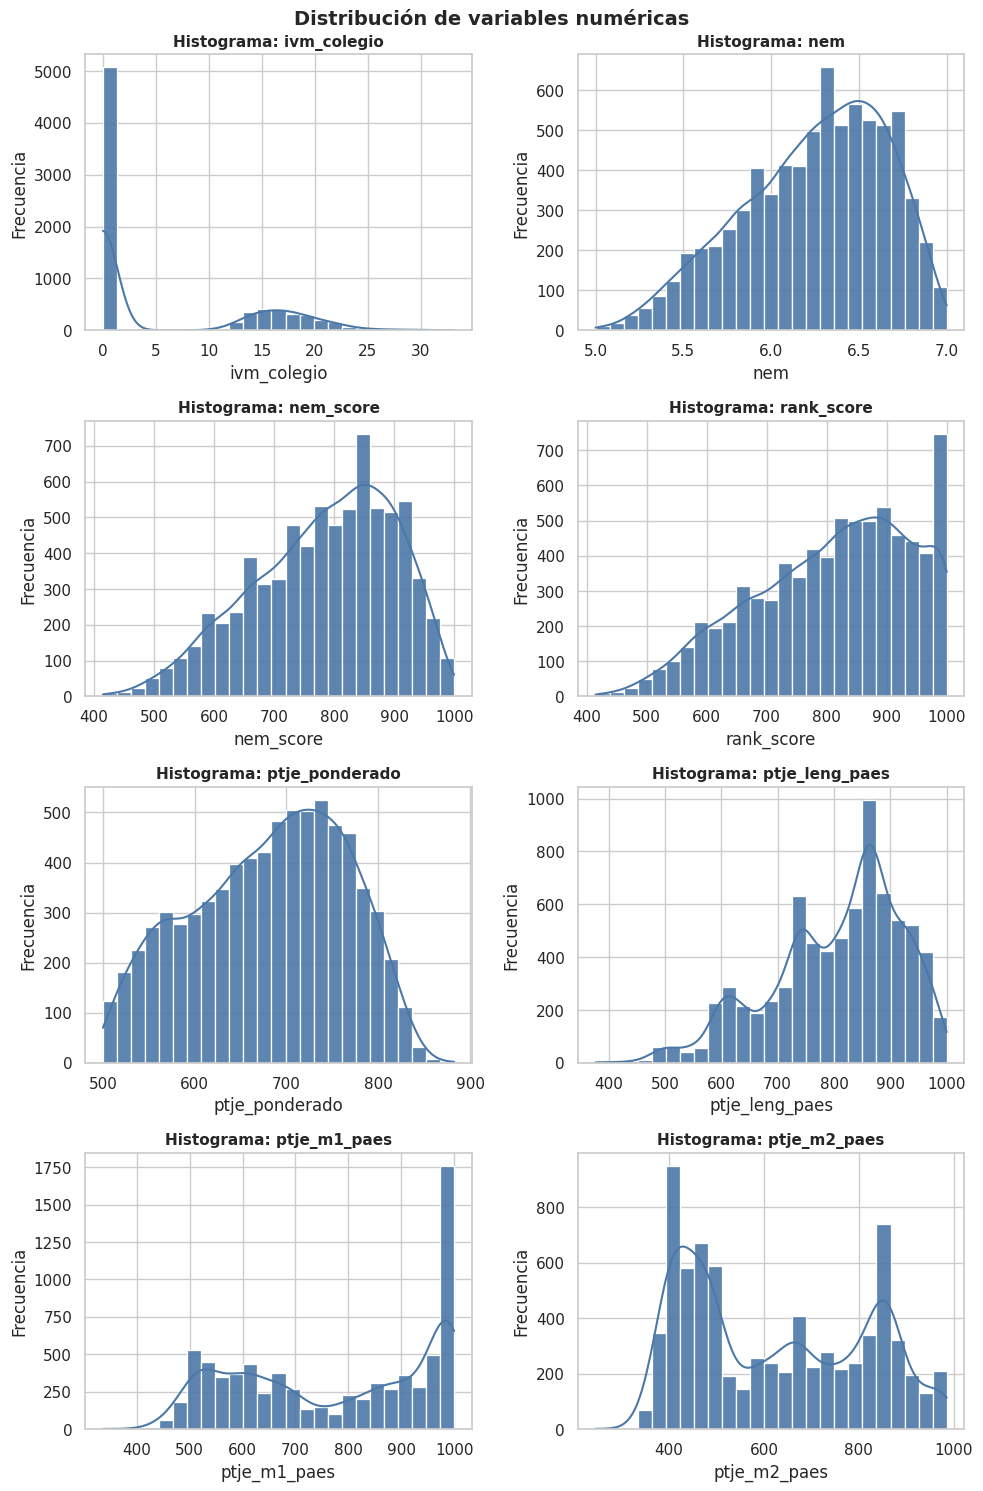

In [16]:


# Estilo bonito
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")

# ---------
# Histogramas para variables numéricas
# ---------
n = len(num_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df, x=col, bins=25, kde=True, ax=axes[i],
        color="#4C78A8", edgecolor="white", alpha=0.9
    )
    axes[i].set_title(f"Histograma: {col}", fontsize=11, weight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables numéricas", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

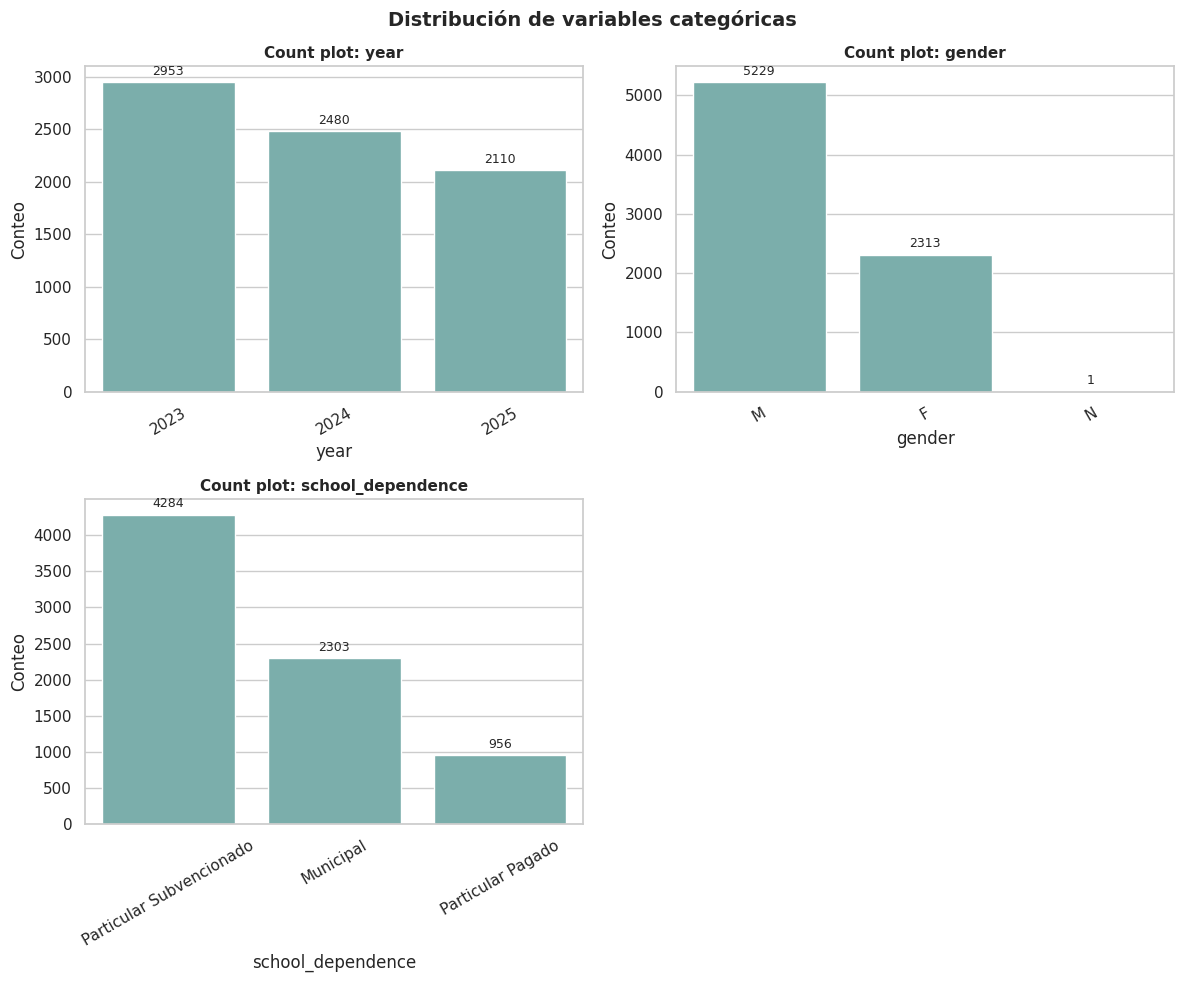

In [20]:
# ---------
# Countplots para variables categóricas
# ---------
n = len(cat_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts(dropna=False).index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], color="#72B7B2")
    axes[i].set_title(f"Count plot: {col}", fontsize=11, weight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Conteo")
    axes[i].tick_params(axis="x", rotation=30)

    # Etiquetas con conteos encima de cada barra
    for p in axes[i].patches:
        h = p.get_height()
        axes[i].annotate(
            f"{int(h)}",
            (p.get_x() + p.get_width()/2, h),
            ha="center", va="bottom", fontsize=9, xytext=(0, 3),
            textcoords="offset points"
        )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de variables categóricas", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


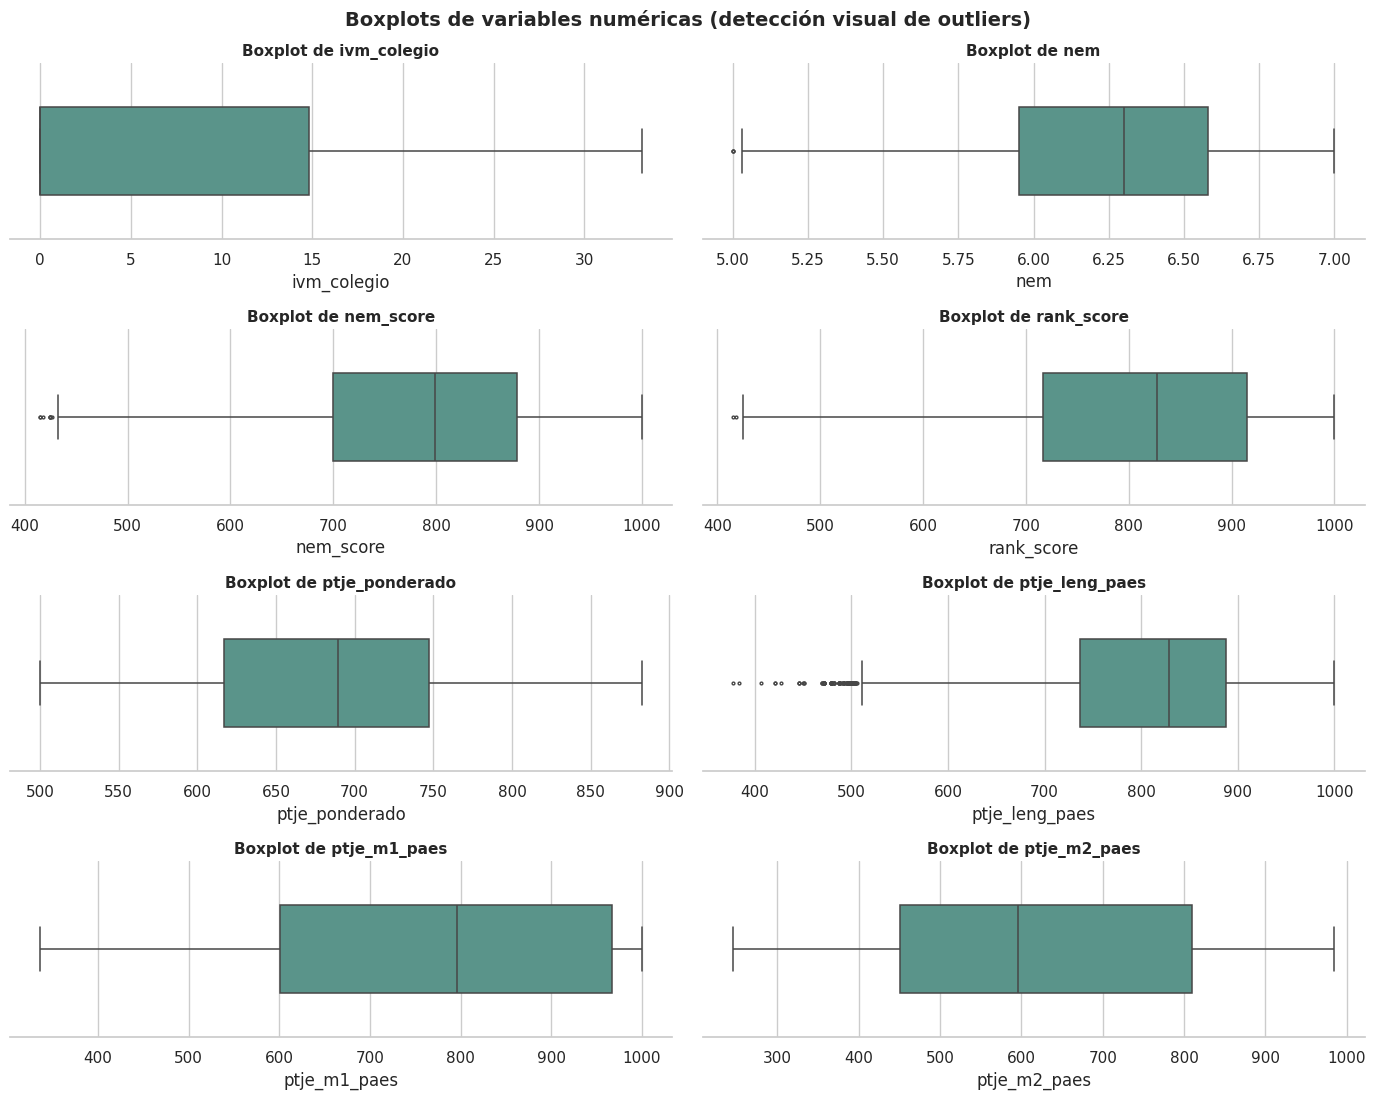

In [25]:
# Estilo (usa tu PALETTE si ya la tienes definida)
sns.set_theme(style="whitegrid", context="notebook")

# Boxplots bonitos en grilla
n = len(num_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 2.8*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(
        x=df[col],                 # horizontal
        ax=ax,
        color=sns.color_palette(PALETTE, 8)[2] if "PALETTE" in globals() else "#72B7B2",
        width=0.5,
        fliersize=2,
        linewidth=1.1
    )
    ax.set_title(f"Boxplot de {col}", fontsize=11, weight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots de variables numéricas (detección visual de outliers)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


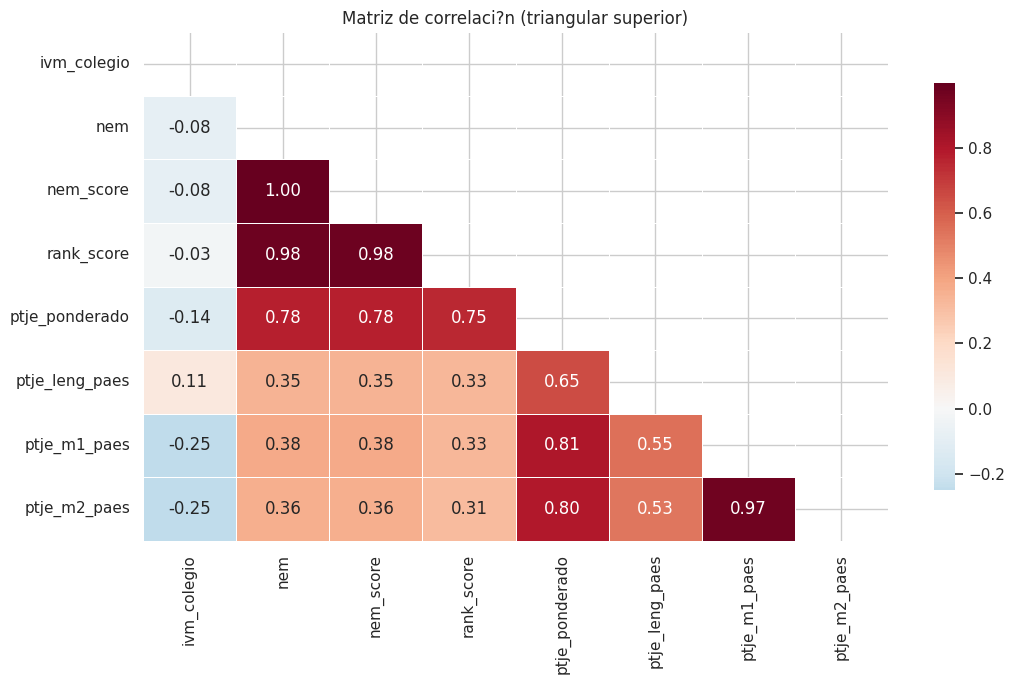

In [ ]:
# Correlaciones (solo numericas)
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlaci?n (triangular superior)')
plt.tight_layout()
plt.show()

4. **Distribuciones**
   - Describe la forma de al menos dos distribuciones observadas en los gráficos (por ejemplo: simétrica, sesgada, multimodal).
   - ¿Qué implicancias podrían tener estas distribuciones para el análisis o la interpretación de los datos?

5. **Relaciones entre variables**
   - ¿Se identifica alguna relación relevante entre variables?
   - ¿Qué visualizaciones respaldan tu análisis?

6. **Interpretación y toma de decisiones**
   - Menciona al menos dos hallazgos relevantes identificados en el análisis.
   - Si estos datos pertenecieran a una organización, ¿qué tipo de decisión o acción podría apoyarse en estos resultados?

**RESPUESTA**: ...